# HVAC Demand analysis and prediction Time series analysis


In [129]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Time Series
import statsmodels.api as sm
import statsmodels.formula as smf
import statsmodels.tsa as smt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
import pmdarima as pm
from pmdarima.model_selection import train_test_split

np.random.seed(42)


In [130]:
df = pd.read_csv("./data/Load_data_01.csv")
df["Time"] = pd.to_datetime(df["Time"])
df.set_index("Time", inplace=True)


In [131]:
demand_2017 = df.query("'2017-01-01' <= Time < '2018-01-01'")


In [132]:
demand_2017


,air_pressure,air_temperature,relative_humidity,wind_speed,solar_irridiation,total_cloud_cover_percent,electricity_demand_values,heat_demand_values
Time,,,,,,,,
2017-01-01 00:00:00,737.5,25.0,64.0,3.0,0,0.00,635.180321,599.496984
2017-01-01 01:00:00,740.0,22.2,64.0,4.0,0,0.75,694.601830,640.536548
2017-01-01 02:00:00,740.0,15.0,93.0,2.0,0,0.00,654.953438,573.867021
2017-01-01 03:00:00,739.7,16.1,84.0,5.0,0,0.00,601.667517,590.384631
2017-01-01 04:00:00,739.7,18.3,61.0,0.0,0,0.00,520.843008,654.104139
...,...,...,...,...,...,...,...,...
2017-12-31 19:00:00,731.0,22.8,79.0,2.0,112,0.50,359.320065,650.438907
2017-12-31 20:00:00,730.6,25.0,71.0,3.0,0,0.00,353.564285,646.653388
2017-12-31 21:00:00,729.3,32.8,44.0,3.0,0,0.75,355.422727,648.152169


In [133]:
demand_2017_1 = df.query("'2017-01-01' <= Time < '2017-02-01'")


<Axes: xlabel='Time'>

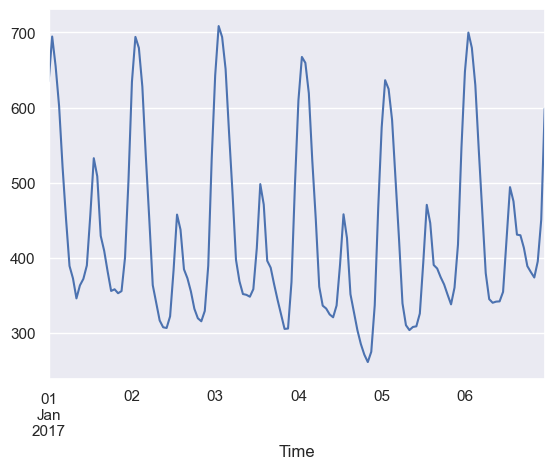

In [142]:
df.query("'2017-01-01' <= Time < '2017-1-7'")['electricity_demand_values'].plot()


In [143]:
demand_17 = df.query("'2017-01-01' <= Time < '2018-01-01'")['electricity_demand_values'] 


In [144]:
model = pm.auto_arima(
    demand_17,
    seasonal=True,
    trace=True,
    m=24,
    error_action="ignore",
    suppress_warnings=True,
)


Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[24] intercept   : AIC=inf, Time=25.01 sec
 ARIMA(0,1,0)(0,0,0)[24] intercept   : AIC=99081.270, Time=0.06 sec
 ARIMA(1,1,0)(1,0,0)[24] intercept   : AIC=85241.620, Time=4.49 sec
 ARIMA(0,1,1)(0,0,1)[24] intercept   : AIC=90352.364, Time=4.80 sec
 ARIMA(0,1,0)(0,0,0)[24]             : AIC=99079.271, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[24] intercept   : AIC=92204.032, Time=0.19 sec
 ARIMA(1,1,0)(2,0,0)[24] intercept   : AIC=inf, Time=99.77 sec
 ARIMA(1,1,0)(1,0,1)[24] intercept   : AIC=inf, Time=9.83 sec
 ARIMA(1,1,0)(0,0,1)[24] intercept   : AIC=88987.183, Time=4.55 sec
 ARIMA(1,1,0)(2,0,1)[24] intercept   : AIC=inf, Time=143.74 sec
 ARIMA(0,1,0)(1,0,0)[24] intercept   : AIC=inf, Time=3.24 sec
 ARIMA(2,1,0)(1,0,0)[24] intercept   : AIC=inf, Time=7.09 sec
 ARIMA(1,1,1)(1,0,0)[24] intercept   : AIC=85197.782, Time=7.89 sec
 ARIMA(1,1,1)(0,0,0)[24] intercept   : AIC=91875.417, Time=0.30 sec
 ARIMA(1,1,1)(2,0,0)[24] intercept   

In [145]:
model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                                   y   No. Observations:                 8760
Model:             SARIMAX(3, 1, 2)x(2, 0, [], 24)   Log Likelihood              -41588.005
Date:                             Sat, 02 Dec 2023   AIC                          83194.010
Time:                                     14:34:48   BIC                          83257.711
Sample:                                 01-01-2017   HQIC                         83215.715
                                      - 12-31-2017                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0003      0.003      0.094      0.925      -0.006       0.007
ar.L1          1.5133      0.035     43.050      0.000       1.444       1.582
ar.L2         -0.4840      0.050     -9.642      0.000      -0.582      -0.386
ar.L3         -0.0819      0.017     -4.777      0.000      -0.116      -0.048
ma.L1         -1.1323      0.035    -32.316      0.000      -1.201      -1.064
ma.L2          0.1428      0.035      4.120      0.000       0.075       0.211
ar.S.L24       0.4704      0.004    110.068      0.000       0.462       0.479
ar.S.L48       0.3867      0.004     96.271      0.000       0.379       0.395
sigma2       794.6254      4.329    183.559      0.000     786.141     803.110
===================================================================================
Ljung-Box (L1) (Q):                   0.30   Jarque-Bera (JB):            174497.52
Prob(Q):                              0.58   Prob(JB):                         0.00
Heteroskedasticity (H):               1.13   Skew:                            -0.47
Prob(H) (two-sided):                  0.00   Kurtosis:                        24.85
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

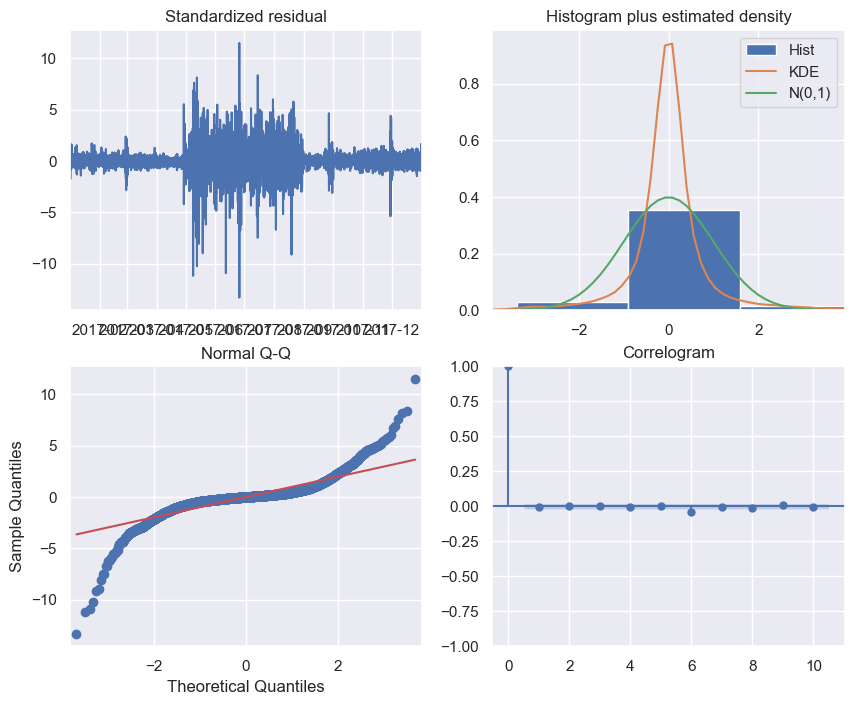

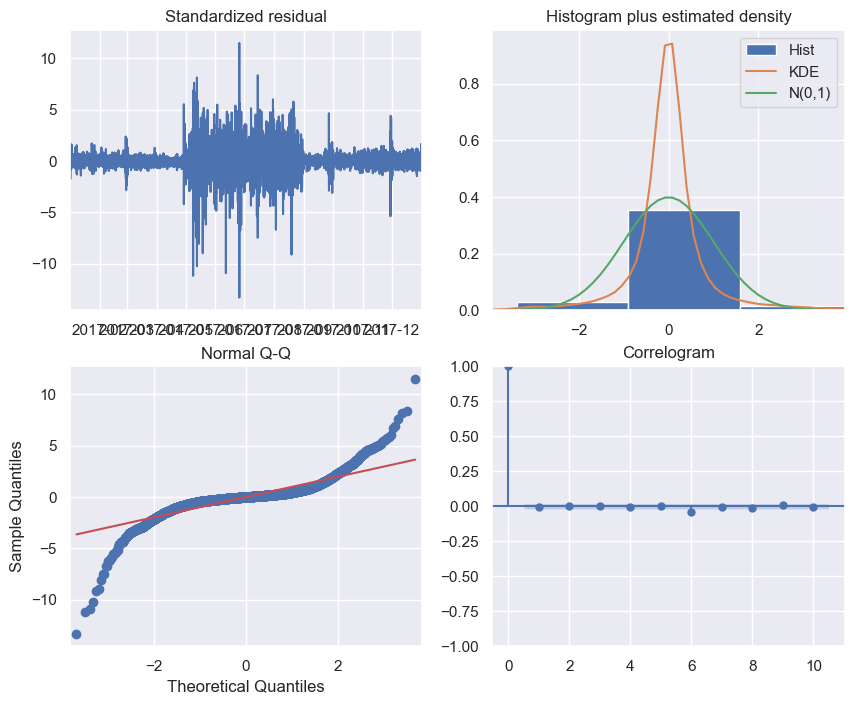

In [146]:
model.plot_diagnostics(figsize=(10, 8))


In [159]:
# test_18 = df.set_index("Time")["electricity_demand_values"].loc[
#     "2018-01-01 00:00:00":"2018-1-1 21:00:00"
# ]

test = df["electricity_demand_values"].loc[
    "2018-02-02 00:00:00":"2018-02-2 23:00:00"
]

forecast = model.predict(n_periods=len(test))
rmse = np.sqrt(mean_squared_error(test, forecast))
r2 = r2_score(test, forecast)
# Print the results
print(f"RMSE: {rmse}")
print(f"R2 Score: {r2}")


RMSE: 141.2921403634968
R2 Score: -0.7433133035073889
